# **Title :** **Ai News Event Clustering & Time Line Builder**

# **Project OverView**

In today’s digital world, the same real-world event is reported by hundreds of news articles across multiple platforms and over different time periods. Because of the large volume of news data, it becomes difficult for users to clearly understand:

* What the actual event is

* How the event evolved over time

* What the important developments or milestones were

This project presents an AI-based News Event Detection and Timeline Generation system that automatically:

 * Group the news articles into real world events

 * Builds a chronological timeline for each event

 * Generates a short summary explainning the event evolution

 This project mainly focuses on:

* Natural Language Processing (NLP)
* Sentence Embeddings and Semantic Understanding
* Unsupervised Machine Learning
* Event Detection and Clustering
* Timeline Analysis and Visualization

# **Future Scope**

The current system successfully performs news event detection, clustering, timeline construction, and event summarization using NLP and machine learning techniques. However, the project can be further improved in several ways in the future.

Possible future enhancements include:

* Real-time news event detection using live news APIs and streaming data.

* Replacing KMeans with advanced clustering algorithms such as DBSCAN or HDBSCAN for better automatic event discovery.

* Using transformer-based summarization models like BART or T5 to generate more accurate and human-like event summaries.

* Building an interactive web dashboard using Streamlit for better visualization and user interaction.

# Loading The Data

In [ ]:
import pandas as pd

df = pd.read_json(r"/content/drive/MyDrive/data/News_Category_Dataset_v3.json.zip",lines=True)

df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [ ]:
# Keeping only useful columns

df = df[["headline","short_description","date"]]

df.head()

,headline,short_description,date
0,Over 4 Million Americans Roll Up Sleeves For O...,Health experts said it is too early to predict...,2022-09-23
1,"American Airlines Flyer Charged, Banned For Li...",He was subdued by passengers and crew when he ...,2022-09-23
2,23 Of The Funniest Tweets About Cats And Dogs ...,"""Until you have a dog you don't understand wha...",2022-09-23
3,The Funniest Tweets From Parents This Week (Se...,"""Accidentally put grown-up toothpaste on my to...",2022-09-23
4,Woman Who Called Cops On Black Bird-Watcher Lo...,Amy Cooper accused investment firm Franklin Te...,2022-09-22


#combining headline + short_description
Becauce both Contain important meaning.

Now each article become one text

In [ ]:
df['text'] = (df['headline'].fillna('')+ " " + df['short_description'].fillna(''))

df["text"].head()


,text
0,Over 4 Million Americans Roll Up Sleeves For O...
1,"American Airlines Flyer Charged, Banned For Li..."
2,23 Of The Funniest Tweets About Cats And Dogs ...
3,The Funniest Tweets From Parents This Week (Se...
4,Woman Who Called Cops On Black Bird-Watcher Lo...


# Cleaning the text

In [ ]:
import re

def clean_text(text):

  text = text.lower()                     # converting text to lowercase

  text = re.sub(r"http\S+", "", text)     # removing urls

  text = re.sub(r'[^a-zA-Z0-9 ]','',text)   # removing special characters except a-z,A-Z,0-9

  text = re.sub(r'\s+',' ',text)            # removing extra spaces

  return text.strip()                      # strip() : remove spaces at start/end


df['clean_text']  = df['text'].apply(clean_text)

# converting date into standard datetime format

In [ ]:
df['date'] = pd.to_datetime(df['date'])

#Convert articles into numerical representations using: Sentence embeddings

We can also use Tf-Idf but sentence embeddings usually give much better clustering

Tf-Idf is based mainly on:

Word counts

word importance

Sentence embeddings understand :

Meaning & Context

They Capture Semantics.

That's why we are using Senetnce embeddings

In [ ]:
!pip install sentence-transformers   # installing

In [ ]:
# importing the model

from sentence_transformers import SentenceTransformer

In [ ]:
# Loading the pretrained Model

model = SentenceTransformer('all-MiniLM-L6-v2')

# this model is fast and very good for semantic similarity

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# Generating Embeddings

sample_df = df.sample(50000,random_state=42)

embeddings = model.encode(sample_df['clean_text'].tolist(),show_progress_bar=True)

# this converts every article into sementic vectors
# 384 dimensional vector

Batches:   0%|          | 0/1563 [00:00<?, ?it/s]

In [ ]:
# Saving embeddings

import numpy as np

np.save('embeddings.npy',embeddings)

# Grouping articles into clusters using **Kmeans**


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10,random_state=42)

clusters = kmeans.fit_predict(embeddings)

In [ ]:
sample_df['cluster'] = clusters

In [ ]:
sample_df['cluster'].value_counts()

,count
cluster,
9,8036
7,6006
8,5954
5,5552
0,5333
4,4747
6,3901
3,3836
2,3449


In [ ]:
sample_df[sample_df['cluster'] == 1].head(20)

,headline,short_description,date,text,clean_text,cluster
139757,Supermodel Stephanie Seymour Does Sexy Photo S...,"In particular, Seymour remembers the way the b...",2014-02-10,Supermodel Stephanie Seymour Does Sexy Photo S...,supermodel stephanie seymour does sexy photo s...,1
184623,Is The Anna Dello Russo For H&M Hat Practical ...,It takes a special kind of girl to sport a stu...,2012-10-22,Is The Anna Dello Russo For H&M Hat Practical ...,is the anna dello russo for hm hat practical f...,1
192658,Kardashian Kurves Contest Launches Sisters' Pl...,See Kim's kurvy style through the years: Final...,2012-07-27,Kardashian Kurves Contest Launches Sisters' Pl...,kardashian kurves contest launches sisters plu...,1
151587,The Wildest Celeb Halloween Costumes,From Heidi Klum's legendary costumes for her a...,2013-10-08,The Wildest Celeb Halloween Costumes From Heid...,the wildest celeb halloween costumes from heid...,1
145267,Prince George Doll Is Almost Too Lifelike... (...,"However, if porcelain dolls are really your th...",2013-12-13,Prince George Doll Is Almost Too Lifelike... (...,prince george doll is almost too lifelike phot...,1
147822,"Trolltunga, Norway Is The Scariest Instagram S...",Wanna climb (and Instagram) Trolltunga too? Ge...,2013-11-16,"Trolltunga, Norway Is The Scariest Instagram S...",trolltunga norway is the scariest instagram sp...,1
158515,New Jersey Mountain Home Is Pretty Much Its Ow...,Have something to say? Check out HuffPost Home...,2013-07-26,New Jersey Mountain Home Is Pretty Much Its Ow...,new jersey mountain home is pretty much its ow...,1
139842,Fashion Week Live Blog: Everything That's Happ...,"Yeah, we know it's Sunday, but more importantl...",2014-02-09,Fashion Week Live Blog: Everything That's Happ...,fashion week live blog everything thats happen...,1
187522,Hotel Suites Good Enough For The President (PH...,The commander-in-chief checks in and out of ro...,2012-09-21,Hotel Suites Good Enough For The President (PH...,hotel suites good enough for the president pho...,1
169218,Funky Freebies And Looney Loaners: The 7 Most ...,When you're shelling out hard-earned cash for ...,2013-04-04,Funky Freebies And Looney Loaners: The 7 Most ...,funky freebies and looney loaners the 7 most i...,1


# Event Labelling

# Understanding what each cluster contains

In [ ]:
for i in range(10):
   print(f"\n==========CLUSTER{i}===========")

   temp = sample_df[sample_df['cluster'] == i]

   headlines = temp['headline'].head(20)

   for h in headlines:
     print("-",h)



==========CLUSTER0===========
- End of the Year
- 6 Tips That Could Help Your Student Loan Repayment
- Why Women Stay in Bad Marriages
- What You Need To Know About Happiness And Depression
- How Raising An Introvert Made Me A Better Educator
- Is Your Outdated Career Map Leading You Astray?
- How to Be Intimate Again After Loss
- 7 Ways to Practice Mindfulness in the Technology Age
- You Don't Need Rose-Colored Glasses: 5 Realistic Tips to Be More Positive
- One Formula to Lead and Live Better: 75+/25-
- Dr. Pat Consults: Alzheimer's Disease Awareness Month
- What If I'm Not as Strong as You Think I Am? A Headache Confession
- How Mindfulness Can Help With Racial Trauma
- I Really Can't Talk My Way Out of Things...
- They Lied to Us About College and Our Careers. What Next?
- Face-Reading: An Advantage in Business
- The Loud Voice of Cancer
- 7 Ways People With Phenomenal Mental Toughness Combat Stress
- 5 Dreamy Nightcaps
- Out of Sight, Out of Mind

==========CLUSTER1===========
- 

# Creating cluster Labels

In [ ]:
cluster_labels = {
    0: "Mental Health & Self Improvement",
    1: "Food, Lifestyle & Health",
    2: "Women, Gender & Social Issues",
    3: "Parenting, Children & Family",
    4: "US Politics & Trump News",
    5: "Crime, Accidents & Public Incidents",
    6: "Elections & Government Policies",
    7: "Global Issues, Science & Public Health",
    8: "Travel, Hotels & Fashion Lifestyle",
    9: "Entertainment & Celebrity News"
}

# Adding labels into dataframe

In [ ]:
sample_df['event_label'] = sample_df['cluster'].map(cluster_labels)

In [ ]:
# verifying results

sample_df[['headline','cluster','event_label']].head(20)

,headline,cluster,event_label
128310,What If We Were All Family Generation Changers?,3,"Parenting, Children & Family"
139983,Firestorm At AOL Over Employee Benefit Cuts,7,"Global Issues, Science & Public Health"
42339,Dakota Access Protesters Arrested As Deadline ...,5,"Crime, Accidents & Public Incidents"
131494,One Glimpse Of These Baby Kit Foxes And You'll...,3,"Parenting, Children & Family"
163649,"Mens' Sweat Pheromone, Androstadienone, Influe...",2,"Women, Gender & Social Issues"
192926,Summer Sleepover Tips,8,"Travel, Hotels & Fashion Lifestyle"
183417,End of the Year,0,Mental Health & Self Improvement
35735,Maybe Colleges Should Take A Lesson From Zoos,7,"Global Issues, Science & Public Health"
139757,Supermodel Stephanie Seymour Does Sexy Photo S...,9,Entertainment & Celebrity News
29057,American Attitudes About Guns Have Become Much...,7,"Global Issues, Science & Public Health"


# Event Time Line Construction

Timeline construction shows how an event changes over time using news articles sorted by date

In [ ]:
sample_df.columns

Index(['headline', 'short_description', 'date', 'text', 'clean_text',
       'cluster', 'event_label'],
      dtype='object')

In [ ]:
# select one cluster
cluster_5 = sample_df[sample_df['cluster'] == 5]

# this contains only Crime,Accidents & Public incidents

In [ ]:
# sort by date

cluster_5 = cluster_5.sort_values(by='date')

cluster_5

,headline,short_description,date,text,clean_text,cluster,event_label
209523,Maria Sharapova Stunned By Victoria Azarenka I...,"Afterward, Azarenka, more effusive with the pr...",2012-01-28,Maria Sharapova Stunned By Victoria Azarenka I...,maria sharapova stunned by victoria azarenka i...,5,"Crime, Accidents & Public Incidents"
209451,'Terminator 3' Star Nick Stahl Arrested For No...,Nick Stahl found himself a little short on cas...,2012-01-29,'Terminator 3' Star Nick Stahl Arrested For No...,terminator 3 star nick stahl arrested for not ...,5,"Crime, Accidents & Public Incidents"
209383,TSA Workers Suspended From Newark Airport For ...,An official with the local union told the site...,2012-01-30,TSA Workers Suspended From Newark Airport For ...,tsa workers suspended from newark airport for ...,5,"Crime, Accidents & Public Incidents"
209257,Secret TSA 'Memo' Reveals The Difference Betwe...,TSA policy on cupcakes and other baked goods i...,2012-01-31,Secret TSA 'Memo' Reveals The Difference Betwe...,secret tsa memo reveals the difference between...,5,"Crime, Accidents & Public Incidents"
209261,Prescription Painkillers: Protect Yourself and...,If you or someone in your family needs a presc...,2012-01-31,Prescription Painkillers: Protect Yourself and...,prescription painkillers protect yourself and ...,5,"Crime, Accidents & Public Incidents"
...,...,...,...,...,...,...,...
49,Podcasters Offer $100K Reward For Information ...,The Las Vegas podcasters are hoping to find ou...,2022-09-15,Podcasters Offer $100K Reward For Information ...,podcasters offer 100k reward for information o...,5,"Crime, Accidents & Public Incidents"
44,Mark Meadows Complies With Justice Dept. Subpo...,The former White House chief of staff has turn...,2022-09-15,Mark Meadows Complies With Justice Dept. Subpo...,mark meadows complies with justice dept subpoe...,5,"Crime, Accidents & Public Incidents"
33,Man Charged With Exposing Himself To Mourners ...,The 19-year-old reportedly fled into the Thame...,2022-09-17,Man Charged With Exposing Himself To Mourners ...,man charged with exposing himself to mourners ...,5,"Crime, Accidents & Public Incidents"
31,Watchdog Report Finds Some Census Takers Who F...,"Despite entering false information, their work...",2022-09-18,Watchdog Report Finds Some Census Takers Who F...,watchdog report finds some census takers who f...,5,"Crime, Accidents & Public Incidents"


In [ ]:
cluster_5[['date','headline']].head(20)

,date,headline
209523,2012-01-28,Maria Sharapova Stunned By Victoria Azarenka I...
209451,2012-01-29,'Terminator 3' Star Nick Stahl Arrested For No...
209383,2012-01-30,TSA Workers Suspended From Newark Airport For ...
209257,2012-01-31,Secret TSA 'Memo' Reveals The Difference Betwe...
209261,2012-01-31,Prescription Painkillers: Protect Yourself and...
209193,2012-02-01,TSA Agent Accused Of Stealing iPads From Trave...
209043,2012-02-02,"Facebook May Be Used Against You In Court, Law..."
209069,2012-02-02,Qantas Flight Grounded By Dirty Diaper
208865,2012-02-04,"Zach Huston, Victim of Brutal Ohio School Bull..."
208787,2012-02-05,Kitten Jail Break (VIDEO)


In [ ]:
# Creating time line for all clusters

for i in range(10):

    print(f"\n========== TIMELINE FOR CLUSTER {i} ==========\n")

    temp = sample_df[
        sample_df['cluster'] == i
    ]

    temp = temp.sort_values('date')

    timeline = temp[
        ['date', 'headline']
    ].head(10)

    print(timeline)


========== TIMELINE FOR CLUSTER 0 ==========

             date                                           headline
209368 2012-01-30  Yoga Journal 21-Day Challenge, Day 21: Yoga Fo...
209349 2012-01-30            Tips To Help Your Dog Deal With Divorce
209371 2012-01-30            23 Ways To Push Through A Tough Workout
209263 2012-01-31  Divorce Study: Splitting More Painful At Young...
209219 2012-01-31  The Couple That Argues Together Stays Together...
209171 2012-02-01  How To Be Organized: 11 Most Common Laundry Mi...
209156 2012-02-01  Living Transformation: Is What You See Really ...
209142 2012-02-01            Divorce Over Infidelity? Not So Fast...
209144 2012-02-01              Conversion Disorder and Mass Hysteria
209088 2012-02-02  Stroke Risk: What Erratic Heart Rhythms May Me...

========== TIMELINE FOR CLUSTER 1 ==========

             date                                           headline
209285 2012-01-31  VOTE! Super Bowl Snacks Bracket Challenge: Rou...
209272 20

In [ ]:
sample_df.head()

,headline,short_description,date,text,clean_text,cluster,event_label
128310,What If We Were All Family Generation Changers?,"What if, in doing so, we won't just create new...",2014-06-20,What If We Were All Family Generation Changers...,what if we were all family generation changers...,3,"Parenting, Children & Family"
139983,Firestorm At AOL Over Employee Benefit Cuts,It should have been a glorious week for AOL ch...,2014-02-08,Firestorm At AOL Over Employee Benefit Cuts It...,firestorm at aol over employee benefit cuts it...,7,"Global Issues, Science & Public Health"
42339,Dakota Access Protesters Arrested As Deadline ...,A few protesters who refused to leave remained...,2017-02-22,Dakota Access Protesters Arrested As Deadline ...,dakota access protesters arrested as deadline ...,5,"Crime, Accidents & Public Incidents"
131494,One Glimpse Of These Baby Kit Foxes And You'll...,,2014-05-14,One Glimpse Of These Baby Kit Foxes And You'll...,one glimpse of these baby kit foxes and youll ...,3,"Parenting, Children & Family"
163649,"Mens' Sweat Pheromone, Androstadienone, Influe...",Scientists didn't know if humans played that g...,2013-06-02,"Mens' Sweat Pheromone, Androstadienone, Influe...",mens sweat pheromone androstadienone influence...,2,"Women, Gender & Social Issues"


# Event Summary Generation

In [ ]:
# We install sumy when we want to perform automatic text summarization in Python.It helps convert long text into shorter summari


!pip install sumy

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 68.2 MB/s eta 0:00:00
  Created wheel for breadability: filename=breadability-0.1.20-py2.py3-none-any.whl size=21695 sha256=3ebc29d242636711f56f4de34cbfe01ce4bbedaca1076cfe4c658555f34d1165
  Stored in directory: /root/.cache/pip/wheels/32/99/64/59305409cacd03aa03e7bddf31a9db34b1fa7033bd41972662
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=dc16d6058f180c10dd224a311bb046e3cb3e3693ed469dd0897de4cbc74d983e
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built breadability docopt


**PlaintextParser**:

converts normal text into a format that sumy can understand.


The summarizer cannot directly process raw text strings.

So the parser:

reads the text

splits it into sentences

prepares the document structure


**LasSummarizer**

This is the actual summarization algorithm.

LSA means:

Latent Semantic Analysis

It finds the most important sentences based on mathematical relationships between words.

In [ ]:
from sumy.parsers.plaintext import PlaintextParser

from sumy.nlp.tokenizers import Tokenizer

from sumy.summarizers.lsa import LsaSummarizer

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
for i in range(10):

    print(f"\n===== EVENT SUMMARY {i} =====\n")

    temp = sample_df[
        sample_df['cluster'] == i
    ]

    text = " ".join(
        temp['headline'].tolist()              # combining Headlines
    )

    parser = PlaintextParser.from_string(      # Creating Parser
        text,
        Tokenizer("english"))


    summarizer = LsaSummarizer()                # Summarizer

    summary = summarizer(
        parser.document,
        3
    )

    for sentence in summary:
        print(sentence)


===== EVENT SUMMARY 0 =====

A Heartbreak Like No Other: One Year Into Trump's America Rest Easy: Myth Busting For Bedding And Mattresses You Decide if Stress Is the "Bad Guy" Why Do Women Prefer Sleep Over Sex?
Oral Hygiene Habits of the Interesting: World's Strongest Man Phil Pfister Abby Franks' GPS Guide For Positive Self-Talk Vet-to-Vet: How We Know It Works Pets Are 'The 1 Percent' Of Animals 8 Reminders That The Best Is Yet To Come Tantra and Relationship Tips Triathletes May Better Tolerate Pain, Study Suggests 7 Signs Divorced Couples Say They Missed | Love + Sex - Yahoo Shine Technology and the Loss of Intimacy Memorial Day Memories 5 Achievable Resolutions for a Longer, Happier Life Why I Am Both Spiritual And Religious Quit Pointing Your Avocado At Me How Daydreaming Can Lead To More Creativity 10 Tips to Encourage Summer Learning Music For A Sound Sleep Till Death (or Illness Or Dementia) Us Do Part?
— The Good Men Project Due Diligence on Diabetes This Beautiful Family W

In [ ]:
final_df = sample_df[['headline','short_description','cluster','event_label','date']]

final_df.head(10)

,headline,short_description,cluster,event_label,date
128310,What If We Were All Family Generation Changers?,"What if, in doing so, we won't just create new...",3,"Parenting, Children & Family",2014-06-20
139983,Firestorm At AOL Over Employee Benefit Cuts,It should have been a glorious week for AOL ch...,7,"Global Issues, Science & Public Health",2014-02-08
42339,Dakota Access Protesters Arrested As Deadline ...,A few protesters who refused to leave remained...,5,"Crime, Accidents & Public Incidents",2017-02-22
131494,One Glimpse Of These Baby Kit Foxes And You'll...,,3,"Parenting, Children & Family",2014-05-14
163649,"Mens' Sweat Pheromone, Androstadienone, Influe...",Scientists didn't know if humans played that g...,2,"Women, Gender & Social Issues",2013-06-02
192926,Summer Sleepover Tips,Here are five ways to get some beauty sleep wh...,8,"Travel, Hotels & Fashion Lifestyle",2012-07-25
183417,End of the Year,"For a moment, let yourself wonder -- and let y...",0,Mental Health & Self Improvement,2012-11-04
35735,Maybe Colleges Should Take A Lesson From Zoos,"By Michael Preston, UCF Forum columnist What w...",7,"Global Issues, Science & Public Health",2017-05-10
139757,Supermodel Stephanie Seymour Does Sexy Photo S...,"In particular, Seymour remembers the way the b...",9,Entertainment & Celebrity News,2014-02-10
29057,American Attitudes About Guns Have Become Much...,"When I was a kid growing up in Washington, D.C...",7,"Global Issues, Science & Public Health",2017-07-27


# **Time Line Visualization**

In [ ]:
import matplotlib.pyplot as plt


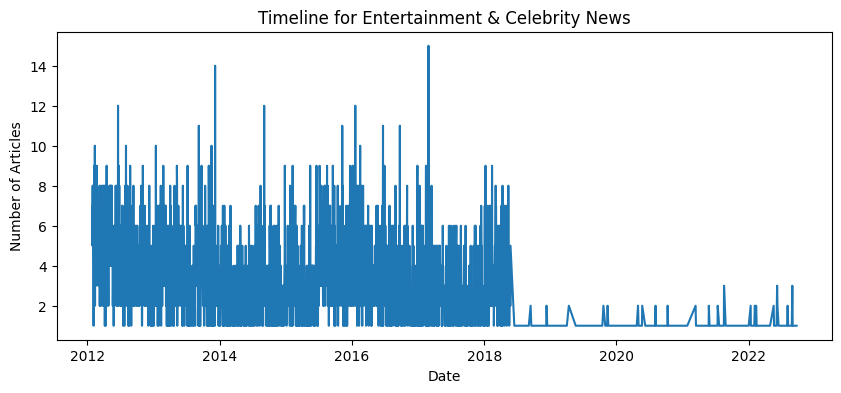

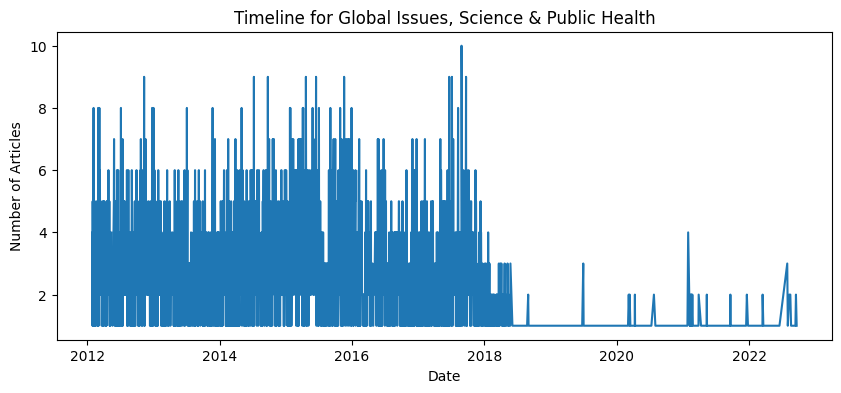

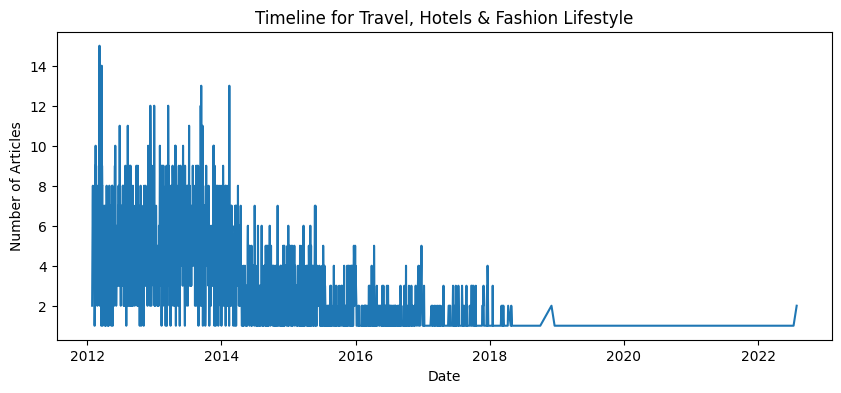

In [ ]:
top_clusters = sample_df['cluster'].value_counts().head(3).index

for cluster_id in top_clusters:

    temp = sample_df[
        sample_df['cluster'] == cluster_id
    ]

    timeline = temp.groupby(
        temp['date'].dt.date
    ).size()

    plt.figure(figsize=(10,4))

    timeline.plot()

    plt.title(
        f"Timeline for {temp['event_label'].iloc[0]}"
    )

    plt.xlabel("Date")

    plt.ylabel("Number of Articles")

    plt.show()

# **Conclusion**

This project successfully developed an AI-based News Event Detection and Timeline Generation system using Natural Language Processing (NLP) and machine learning techniques.

The system analyzed large collections of news articles and automatically grouped semantically similar articles into meaningful event clusters. Sentence embeddings were used to capture contextual meaning from news text, while KMeans clustering helped identify related events and topics effectively.

The project also generated chronological timelines to visualize how events evolved over time and produced concise event summaries for better understanding. Event labeling and article grouping further improved the interpretability of detected events.

Overall, the project demonstrates how NLP, semantic embeddings, and unsupervised learning techniques can be applied to organize large-scale news data into structured and understandable event information. The developed system can help users quickly understand important events, their progression, and related news articles without manually analyzing massive amounts of textual data.

In [ ]:
final_df.to_csv("clustered_news.csv",index=False)

In [ ]:
from google.colab import files
files.download("clustered_news.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
print(os.path.getsize("clustered_news.csv"))

11134884


# Installing Streamlit

In [ ]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 103.9 MB/s eta 0:00:00


# Creatig Streamlit App file

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd

# ---------------- PAGE SETTINGS ----------------

st.set_page_config(
    page_title="AI News Event Clustering Dashboard",
    layout="wide"
)

# ---------------- LOAD DATA ----------------

df = pd.read_csv("clustered_news.csv")

# ---------------- SIDEBAR ----------------

st.sidebar.title("Filters")

# Cluster filter
cluster_option = st.sidebar.selectbox(
    "Select Cluster",
    sorted(df["cluster"].unique())
)

# Search filter
search = st.sidebar.text_input("Search Headlines")

# ---------------- FILTERING ----------------

filtered_df = df[df["cluster"] == cluster_option]

# Search filter
if search:
    filtered_df = filtered_df[
        filtered_df["headline"].str.contains(
            search,
            case=False,
            na=False
        )
    ]

# ---------------- TITLE ----------------

st.title("AI News Event Clustering Dashboard")

# ---------------- METRICS ----------------

col1, col2, col3 = st.columns(3)

col1.metric("Total Articles", len(df))

col2.metric("Total Clusters", df["cluster"].nunique())

col3.metric("Filtered Articles", len(filtered_df))

# ---------------- CHARTS ----------------

st.subheader("Cluster Distribution")

cluster_counts = df["cluster"].value_counts().sort_index()

st.bar_chart(cluster_counts)

# ---------------- EVENT LABEL CHART ----------------

st.subheader("Event Label Distribution")

event_counts = df["event_label"].value_counts()

st.bar_chart(event_counts)

# ---------------- FILTERED ARTICLES ----------------

st.subheader("Filtered News Articles")

if len(filtered_df) == 0:

    st.warning("No articles found")

else:

    for index, row in filtered_df.iterrows():

        st.markdown(f"## {row['headline']}")

        # Description
        if pd.notna(row["short_description"]):
            st.write(row["short_description"])
        else:
            st.write("No description available")

        # Date
        st.write("📅 Date:", row["date"])

        # Event label
        st.write("🏷️ Event Label:", row["event_label"])

        st.write("---")

# ---------------- COMPLETE DATASET ----------------

with st.expander("View Complete Dataset"):

    st.dataframe(df)

Writing app.py


In [ ]:
!streamlit run app.py &>/content/logs.txt &

# Creating public link

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3DXa1osFqxTJVyhbTAO0ZT077tz_5KB4NL6XeEs7BWEjAwsBs")


In [ ]:
from pyngrok import ngrok
public_url = ngrok.connect(8501)

print(public_url)


NgrokTunnel: "https://darkness-alone-during.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
%%writefile requirement.text

streamlit
pandas
scikit-learn
matplotlib

Writing requirement.text
